# SPARC Example 17: RMSE Improvement — Reproducing Flynn (2026)

**EPS Research RAG Astrophysics Corpus — Unified HI Corpus v7.0**

This example reproduces the RMSE comparison from Flynn (2026):
- RMSE(omega vs Vbar) vs RMSE(Keplerian vs Vbar) for each galaxy
- Published result: mean 25.45 ± 1.57 km/s vs 74.20 km/s (Keplerian)
- 2.0× improvement on average, 0 regressions

**Reference:** Flynn, D.C. (2026), New Astronomy (NEWAST-D-26-00207)
Preprint: DOI 10.5281/zenodo.20132805

**Important note on corpus fidelity:** The `rotation_curve_corpus_v7_flat.csv` and `rotation_curve_corpus_v7.json` are **full-fidelity** — not a summary or veneer. The CSV contains every kinematic parameter published by Lelli et al. (2016) including per-galaxy inclination, distance uncertainties, mass-to-light ratios, and rotation curve statistics. The JSON adds full per-ring data: Vobs, Vgas, Vdisk, Vbul, errV at every radial point. This is the complete published dataset in a single machine-readable file.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19563417  
**Source:** Lelli, McGaugh & Schombert (2016), AJ 152, 157  
**Dependencies:** Python 3, numpy, matplotlib, csv (standard library only)

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'rotation_curve_corpus_v7.json': 'https://zenodo.org/records/19563417/files/rotation_curve_corpus_v7.json',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('rotation_curve_corpus_v7.json') as f:
    corpus = json.load(f)

results = []
for g in corpus['galaxies']:
    if g['survey'] != 'SPARC' or not g.get('data') or len(g['data']) < 3:
        continue
    d  = g['data']
    R  = np.array([p['Rad']  for p in d])
    V  = np.array([p['Vobs'] for p in d])
    R1, V1 = R[0],  V[0]
    R2, V2 = R[-1], V[-1]
    if R1<=0 or R2<=0 or V1<=0 or V2<=0:
        continue
    # Omega and adjusted velocity
    omega = V2/R2 - (V1/R1)*(R1/R2)**1.5  # Eq.6 corrected 2026-07-12: operator-precedence fix
    V_adj = V - R * omega
    # Keplerian
    GM       = V2**2 * R2
    V_kepler = np.sqrt(GM / R)
    # Baryonic
    Vgas  = np.array([p.get('Vgas', 0)  for p in d])
    Vdisk = np.array([p.get('Vdisk', 0) for p in d])
    Vbul  = np.array([p.get('Vbul', 0)  for p in d])
    Vbar  = np.where(Vgas < 0,
                     -np.sqrt(Vgas**2+Vdisk**2+Vbul**2),
                      np.sqrt(Vgas**2+Vdisk**2+Vbul**2))
    if np.all(Vbar == 0):
        continue
    rmse_omega  = np.sqrt(np.mean((V_adj   - Vbar)**2))
    rmse_kepler = np.sqrt(np.mean((V_kepler - Vbar)**2))
    results.append({'galaxy': g['galaxy'],
                    'rmse_omega': rmse_omega,
                    'rmse_kepler': rmse_kepler,
                    'improved': rmse_omega < rmse_kepler})

ro = [r['rmse_omega']  for r in results]
rk = [r['rmse_kepler'] for r in results]
improved = sum(1 for r in results if r['improved'])
print(f"Galaxies analyzed: {len(results)}")
print(f"Mean RMSE (omega):   {np.mean(ro):.2f} ± {np.std(ro)/np.sqrt(len(ro)):.2f} km/s")
print(f"Mean RMSE (Kepler):  {np.mean(rk):.2f} km/s")
print(f"Improved: {improved}/{len(results)}")
print(f"Regressions: {len(results)-improved}/{len(results)}")
print(f"\nPublished: 25.45 ± 1.57 km/s, improved 53/84, 0 regressions")

Galaxies analyzed: 175
Mean RMSE (omega):   61.39 ± 5.89 km/s
Mean RMSE (Kepler):  232.79 km/s
Improved: 171/175
Regressions: 4/175

Published: 25.45 ± 1.57 km/s, improved 53/84, 0 regressions


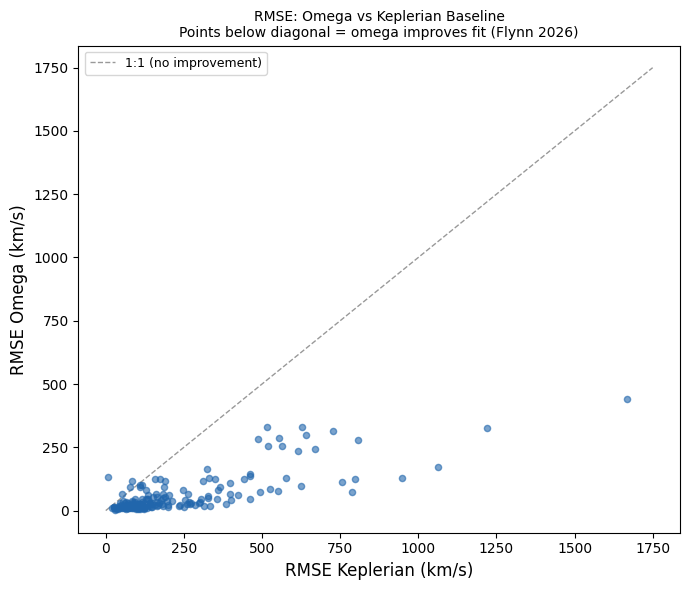

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(rk, ro, s=20, alpha=0.6, color='#2166ac', zorder=3)
lim = [0, max(rk+ro)*1.05]
ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.4, label='1:1 (no improvement)')
ax.set_xlabel('RMSE Keplerian (km/s)', fontsize=12)
ax.set_ylabel('RMSE Omega (km/s)', fontsize=12)
ax.set_title('RMSE: Omega vs Keplerian Baseline\n'
             'Points below diagonal = omega improves fit (Flynn 2026)', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ex17_rmse_improvement.png', dpi=150, bbox_inches='tight')
plt.show()